# 2cm2, full trajectory — 3-dimensional softmax-ISA ISOKANN, POCKET features (lag=20)

Same pipeline as `../dim3_lig/2cm2_isokann_dim3_lig.ipynb`, but trained on the **pocket**
feature set (`data.build_features_pocket`): whole-protein side-chain COM<->COM distances
(40,470 pairs, unchanged count from the original protein-only scheme, just side-chain-only
COM instead of whole-residue COM) PLUS all-atom (hydrogens included, both sides)
ligand<->protein distances restricted to the specific atom pairs that ever come within 5 A
of each other over the FULL trajectory (6,341 pairs) -- **no** separate ligand-COM<->
residue-COM term (dropped; the reasoning is that any allosteric effect of the ligand on
distant residues is already transmitted through the protein's own side-chain-COM network
once the near-pocket residues respond to it directly).

**Why this exists**: `../dim3_lig/`'s chi-MEP work showed hydrogens lagging behind
heavy-atom jumps in the rendered MFEP -- they had exactly zero gradient in that feature
set. This gives the near-pocket atoms (ligand AND the ~37 contacting residues) full
atom-level (H included) treatment, at essentially the SAME total feature count (46,811 vs
46,455) -- see `data.py`'s pocket design note for why a locality-restricted all-atom
scheme stays this cheap while an all-atom scheme over the WHOLE protein would not
(quadratic blow-up, ~59x-518x more features, memory-infeasible).

**Self-consistency note**: `chi` below is recomputed fresh from the trained net's
`net_state`, not `run.get_model`'s cached `chi` (see `comfeat.load_trained_model_pocket`'s
docstring for why the two can disagree).


In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch

LIB = os.path.abspath(os.path.join("..", "..", "2cm2", "lib"))
FULLIB = os.path.abspath(os.path.join("..", "lib"))
sys.path.insert(0, LIB)
sys.path.insert(0, FULLIB)
import data, analysis as A, run, train
import comfeat
from amore.isokann import ChiNetMulti

data.LAG = 20
data.NSTART = 0
data.NEND = 2979
K = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 120
print("selection:", data.SELECTION, "| ligand resname:", data.LIG_RESNAME,
      "| frames", data.NSTART, "..", data.NEND, "| lag", data.LAG)

selection: protein and not element H | ligand resname: KB8 | frames 0 .. 2979 | lag 20


## 1–2. Pocket features + training (cached per k), self-consistent chi
Trains (or loads the cache) via `run.get_model(K, pocket=True)`, then recomputes `chi` fresh from `net_state` on the cached `D0` -- see the self-consistency note above.

In [2]:
feats = data.build_features_pocket(use_pbc=True, verbose=True)
m = run.get_model(K, pocket=True, verbose=True)
NSTART = m["nstart"]
print(f"features: {feats['D0'].shape[-1]} total ({len(feats['res_pairs'])} sidechain-COM-COM "
      f"+ {feats['n_contact']} ligand-protein all-atom contact)")

net = ChiNetMulti(feats["D0"].shape[-1], K, hidden=m["hidden"]).to(DEVICE)
net.load_state_dict(m["net_state"]); net.eval()
_, _, mu, sd = train.normalise(feats["D0"], feats["Dt"])
model = comfeat.NormalizedChiNet(net, mu.numpy(), sd.numpy()).to(DEVICE); model.eval()
with torch.no_grad():
    chi = model(torch.as_tensor(np.asarray(feats["D0"]), dtype=torch.float32,
                                 device=DEVICE)).cpu().numpy()

print("chi (self-consistent with net_state)", chi.shape,
      "| per-membership std:", chi.std(0).round(3),
      "| k_eff:", int((chi.std(0) > 0.05).sum()))
print("cached (possibly stale) chi std:", np.asarray(m["chi"]).std(0).round(3))

[features_pocket] loading cache /scratch/htc/jkresse/2cm2/features_pocket_0_2979_lag20_pbc_rcut25.pt


[model] loading cache /scratch/htc/jkresse/2cm2/model_k3_pocket_0_2979_lag20_pbc.pt


features: 23212 total (16871 sidechain-COM-COM + 6341 ligand-protein all-atom contact)


chi (self-consistent with net_state) (2979, 3) | per-membership std: [0.439 0.408 0.093] | k_eff: 3
cached (possibly stale) chi std: [0.403 0.439 0.348]


## 3. Loss curves and memberships along the trajectory

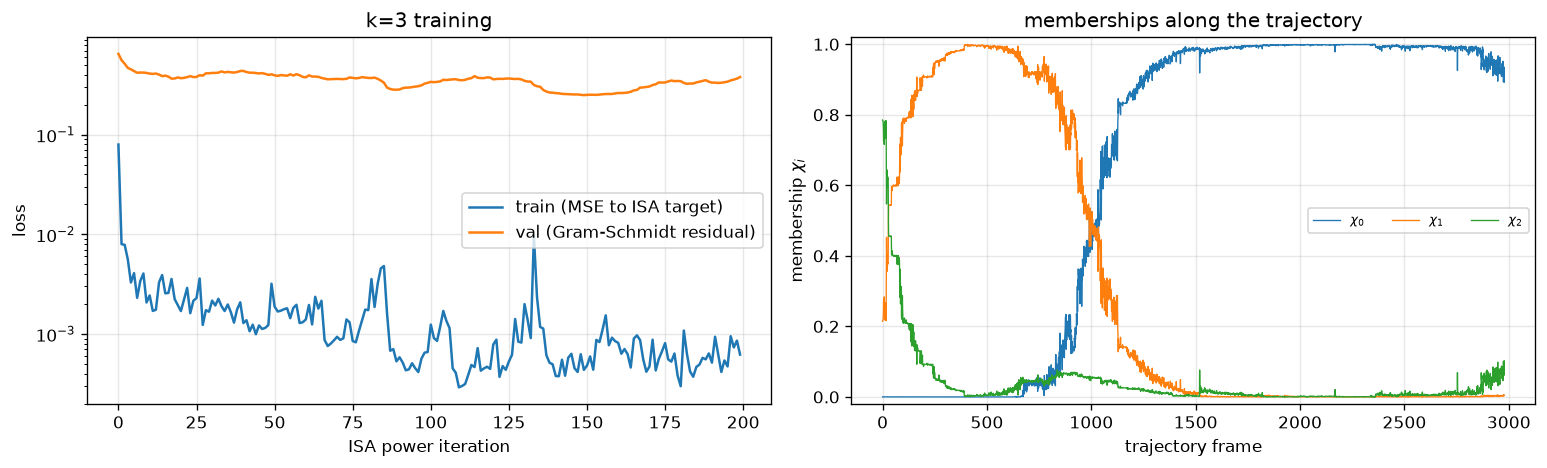

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
A.plot_loss(m, ax=ax[0])
A.plot_chi_trajectory(chi, NSTART, ax=ax[1])
plt.tight_layout(); plt.savefig("loss_and_chi.png", dpi=600, bbox_inches="tight"); plt.show()

The k=3 memberships visualise directly as the barycentric **simplex triangle** (each vertex = one metastable state) -- same plot `dim3/`/`dim3_lig/` used, now on the self-consistent pocket-feature chi.

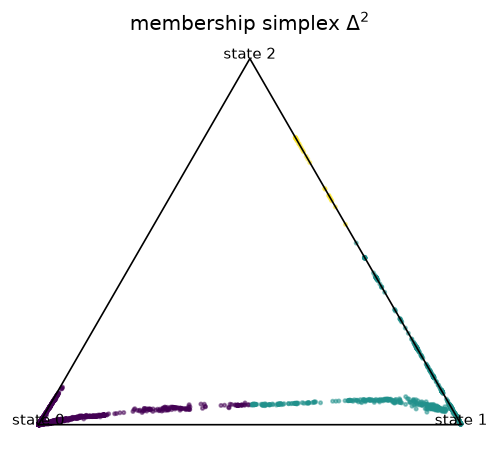

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
A.plot_simplex_triangle(chi, ax=ax)
plt.savefig("simplex_triangle.png", dpi=600, bbox_inches="tight"); plt.show()

## 4. Simplex edges — transition population and rare edges
For each edge $(i,j)$: `on_edge` counts frames with $\chi_i+\chi_j\ge0.8$, `transition` counts the subset with intermediate $s_{ij}\in[0.15,0.85]$ (genuine transition-state frames).  An edge is **relevant** when both endpoint states are visited, and **rare** when its transition count is far below the median relevant edge.

   edge  on_edge  transition  pop_i  pop_j  relevant  rare
    0-2     1852           0   1850      0     False      
    1-2      915         170    732      0     False      
    0-1     2845         317   1850    732      True      

rare simplex edges: none


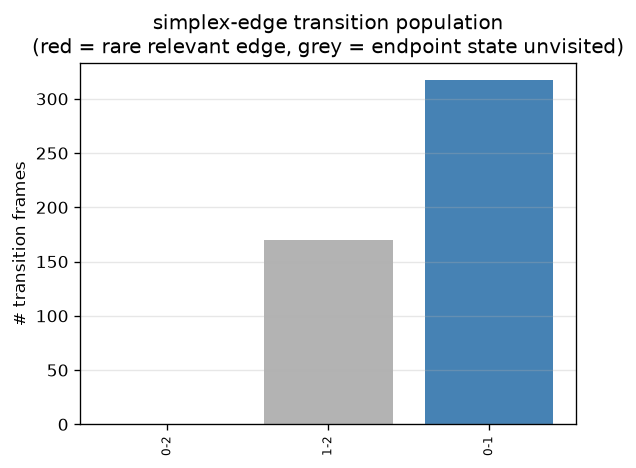

In [5]:
rows = A.edge_table(chi)
rare = A.rare_edges(rows)
print(A.format_edge_table(rows, rare))
print("\nrare simplex edges:", rare if rare else "none")

fig, ax = plt.subplots(figsize=(max(5, 0.5 * len(rows)), 4))
A.plot_edge_populations(rows, rare, ax=ax)
plt.tight_layout(); plt.savefig("edge_populations.png", dpi=600, bbox_inches="tight"); plt.show()

## 4b. Coarse-grained rate matrix (a principled cross-check on the edge table)
`amore.inverse_pcca.rate_matrix`: `Q = logm(Lambda_S) / tau`, the continuous-time generator of the coarse propagator `Lambda_S`.

In [6]:
from amore.inverse_pcca import inverse_pcca, rate_matrix, plot_rate_matrix

Dtn_full = train.normalise(feats["D0"], feats["Dt"])[1].to(DEVICE)
Nq, Kbq, Fq = Dtn_full.shape

def propagate_q():
    with torch.no_grad():
        flat = Dtn_full.reshape(Nq * Kbq, Fq)
        return model(flat).reshape(Nq, Kbq, -1).mean(1).cpu().numpy()

try:
    rate_result = inverse_pcca(chi, propagate_q, float(data.LAG), reversible=True)
except ValueError as e:
    print(f"reversible=True failed ({e})\n-> falling back to reversible=False (Schur route)")
    rate_result = inverse_pcca(chi, propagate_q, float(data.LAG), reversible=False)
Q = rate_matrix(rate_result.Lambda_S, float(data.LAG))
print(f"Lambda_S row sums: {rate_result.Lambda_S.sum(1).round(4)}")
print(f"invariance residual (RMS/entry): {rate_result.residual/np.sqrt(chi.size):.4f}")
print("coarse rate matrix Q (per frame):")
print(Q.round(5))
print("row sums (should be 0):", Q.sum(1).round(8))

edge_rank_frames = sorted(((r["transition"], r["edge"]) for r in rows if r["relevant"]), reverse=True)
edge_rank_rate = sorted(((abs(Q[i, j]) + abs(Q[j, i]), (i, j))
                         for i in range(K) for j in range(i + 1, K)), reverse=True)
print("\nedge ranking by transition-frame count:", [e for _, e in edge_rank_frames])
print("edge ranking by |rate|:              ", [e for _, e in edge_rank_rate])

Lambda_S row sums: [1. 1. 1.]
invariance residual (RMS/entry): 0.0125
coarse rate matrix Q (per frame):
[[-1.300e-04  0.000e+00  1.300e-04]
 [ 4.959e-02 -5.000e-02  4.100e-04]
 [ 4.388e-02  7.000e-05 -4.395e-02]]
row sums (should be 0): [ 0. -0.  0.]

edge ranking by transition-frame count: [(0, 1)]
edge ranking by |rate|:               [(0, 1), (0, 2), (1, 2)]


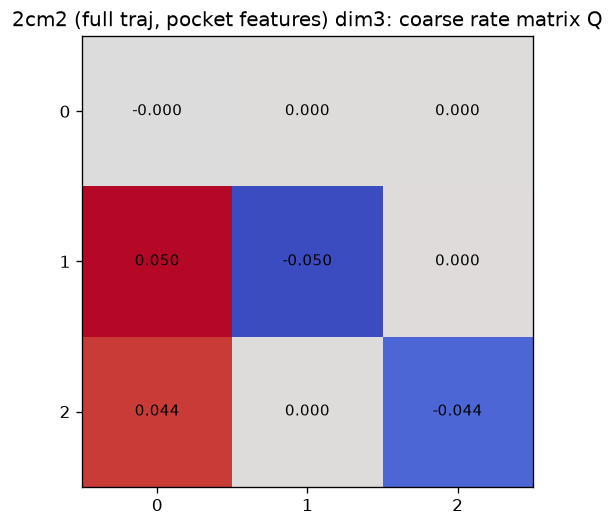

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_rate_matrix(ax, Q, title=f"2cm2 (full traj, pocket features) dim{K}: coarse rate matrix Q")
plt.tight_layout(); plt.savefig("rate_matrix.png", dpi=600, bbox_inches="tight"); plt.show()

## 5. Metastable-state renders (PyMOL)
One 4K PNG per state -- the main deliverable for judging whether all 3 states are genuinely distinct, on the new pocket features.

/home/htc/jkresse/AMORE/.venv/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:309: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "
/home/htc/jkresse/AMORE/.venv/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


  [render] PBC unwrap enabled (bonds guessed)


/home/htc/jkresse/AMORE/.venv/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/htc/jkresse/AMORE/.venv/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


  state 0: rep frame 2925 (chi=0.950), 13 frames -> /home/htc/jkresse/AMORE/examples/2cm2_full/dim3_pocket/states/state_0


  state 1: rep frame 653 (chi=0.950), 13 frames -> /home/htc/jkresse/AMORE/examples/2cm2_full/dim3_pocket/states/state_1


  state 2: rep frame 0 (chi=0.785), 1 frames -> /home/htc/jkresse/AMORE/examples/2cm2_full/dim3_pocket/states/state_2


  state 0 -> OK state_0.png  


  state 1 -> OK state_1.png  


  state 2 -> OK state_2.png  


state 0: state_0.png  (+ state_0.pse)


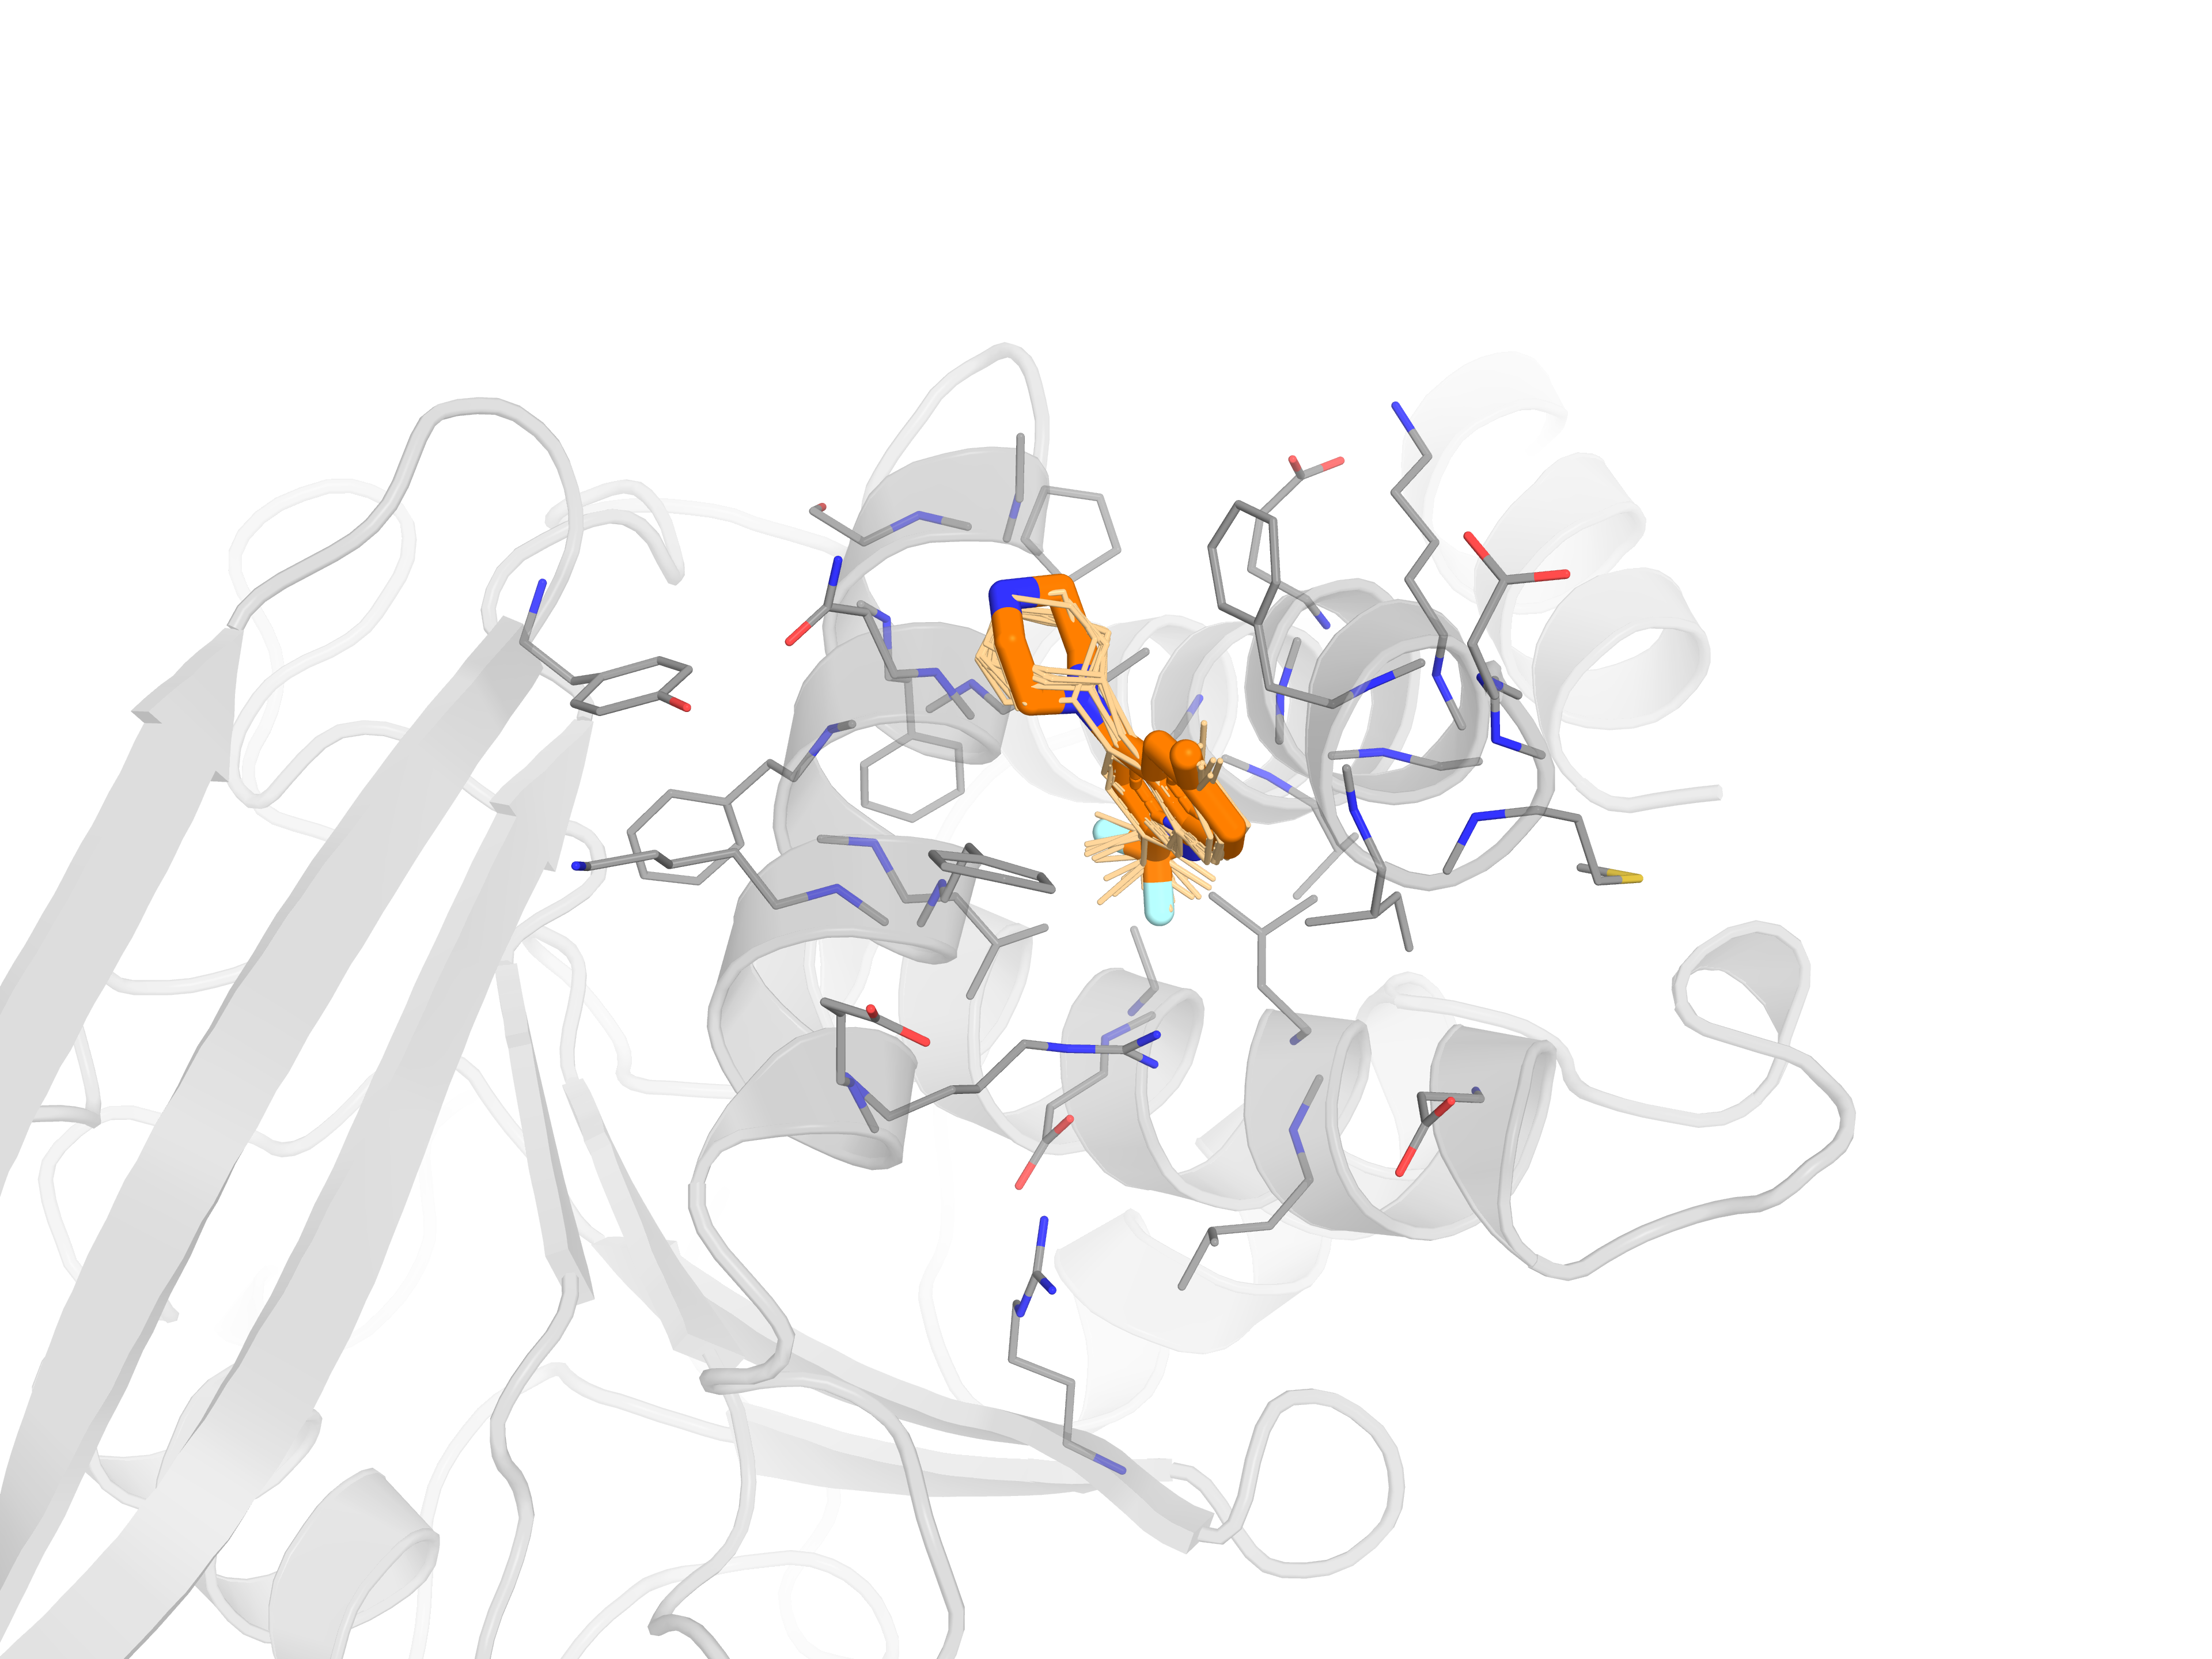

state 1: state_1.png  (+ state_1.pse)


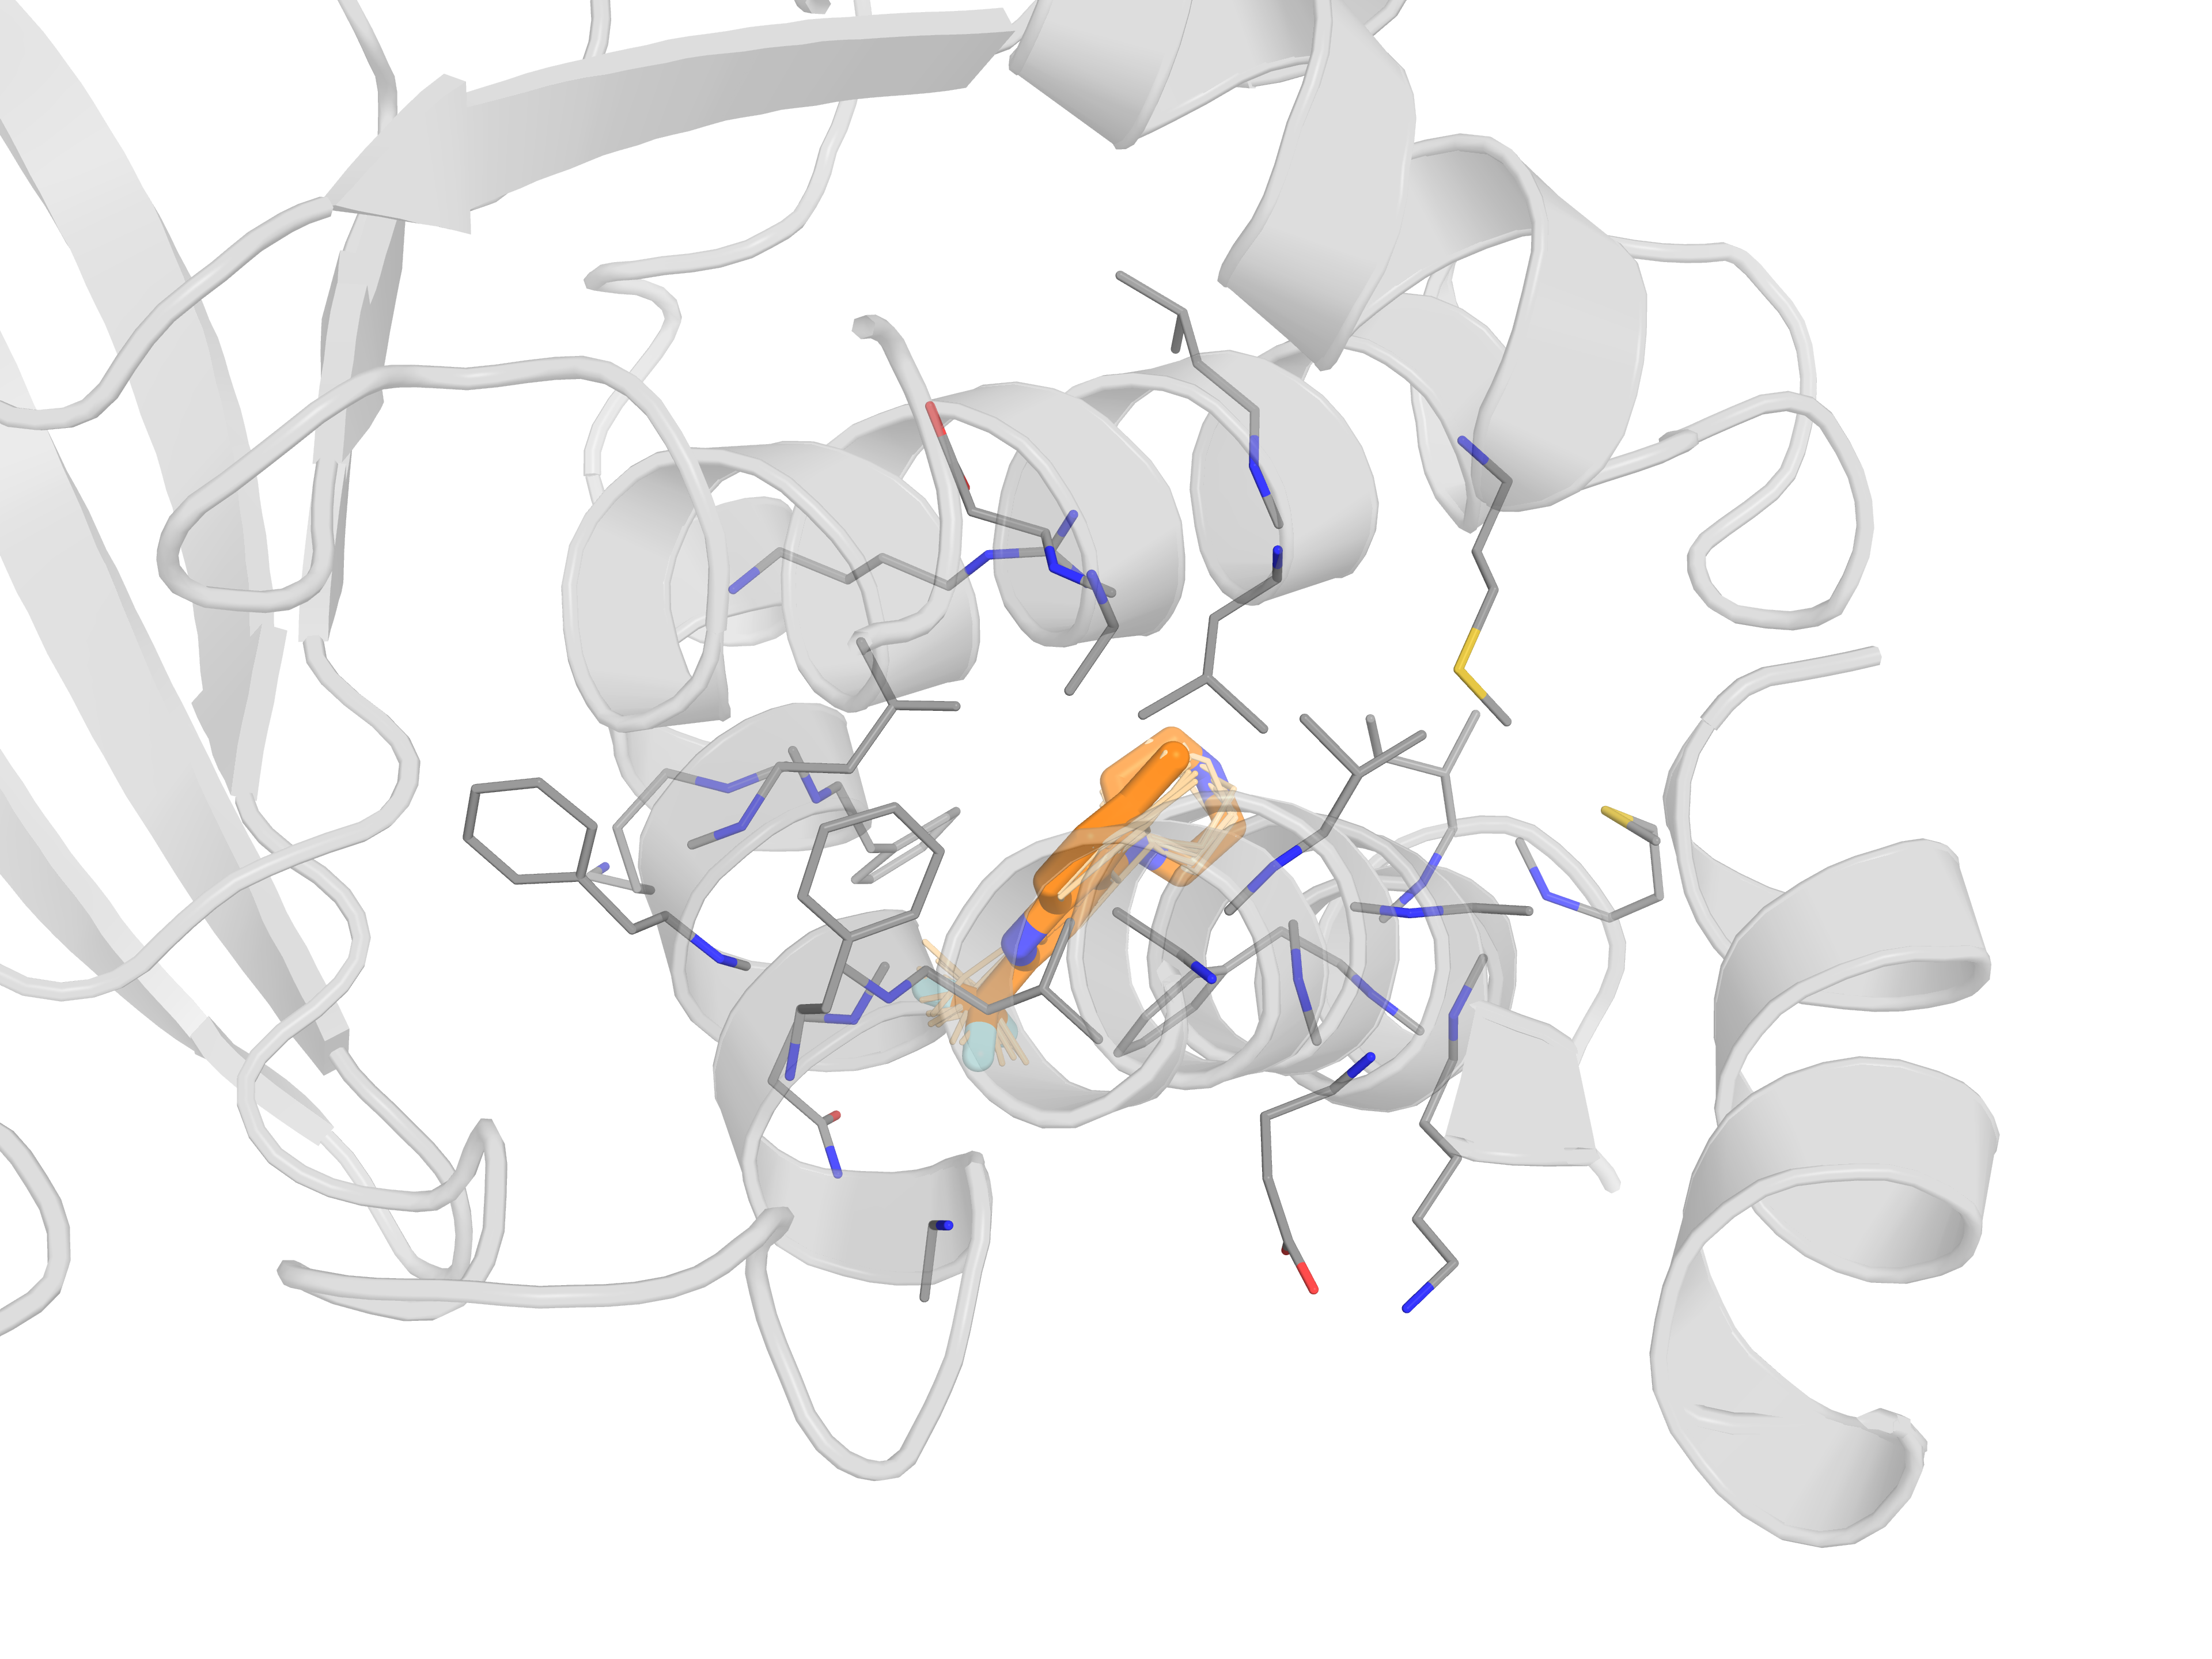

state 2: state_2.png  (+ state_2.pse)


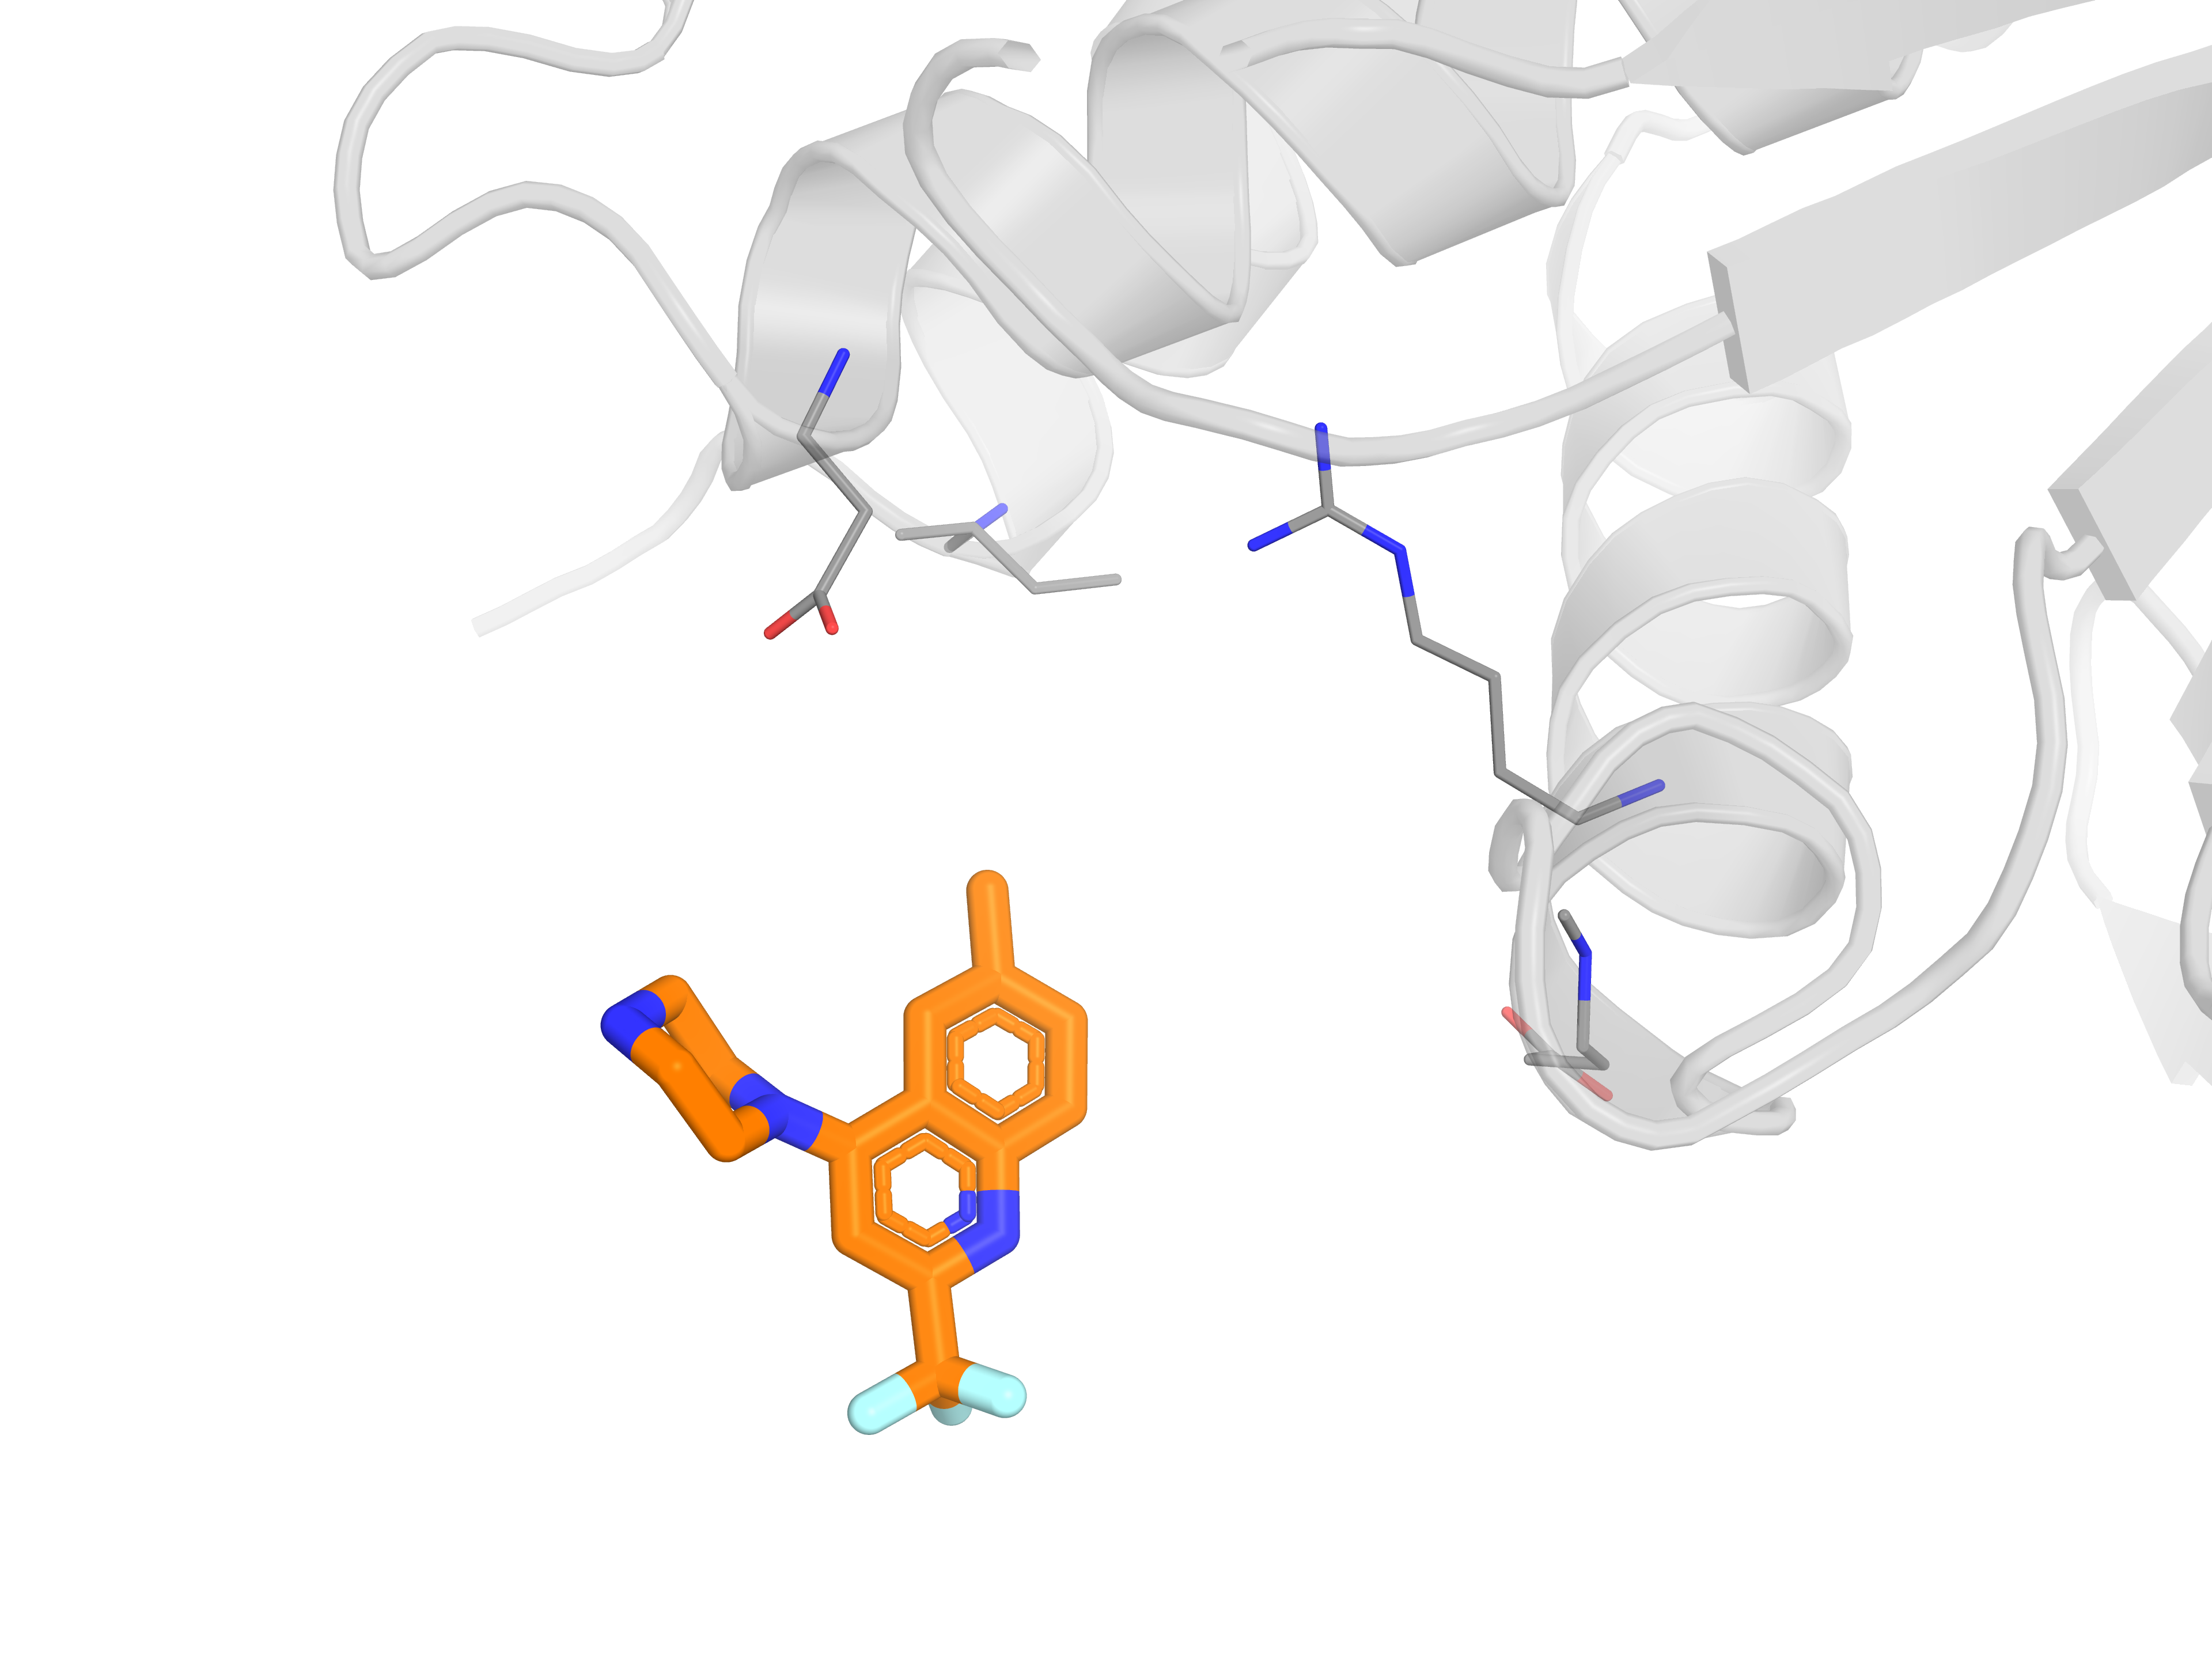

In [8]:
import render
from IPython.display import Image, display

state_dir = os.path.abspath("states")
infos = render.export_state_structures(chi, K, state_dir, nstart=NSTART, verbose=True)
state_pngs = render.render_states(infos, state_dir, verbose=True)
for i, p in enumerate(state_pngs):
    print(f"state {i}: {os.path.basename(p)}  (+ {os.path.basename(p)[:-4]}.pse)")
    display(Image(filename=p, width=560))

## 6. Per-edge transition-pathway sessions (PyMOL `.pse`)

  edge 0-1: 60 frames (s 0.00->1.00)


edge 0-1: 60 frames, s 0.00->1.00  -> OK edge_0-1.pse


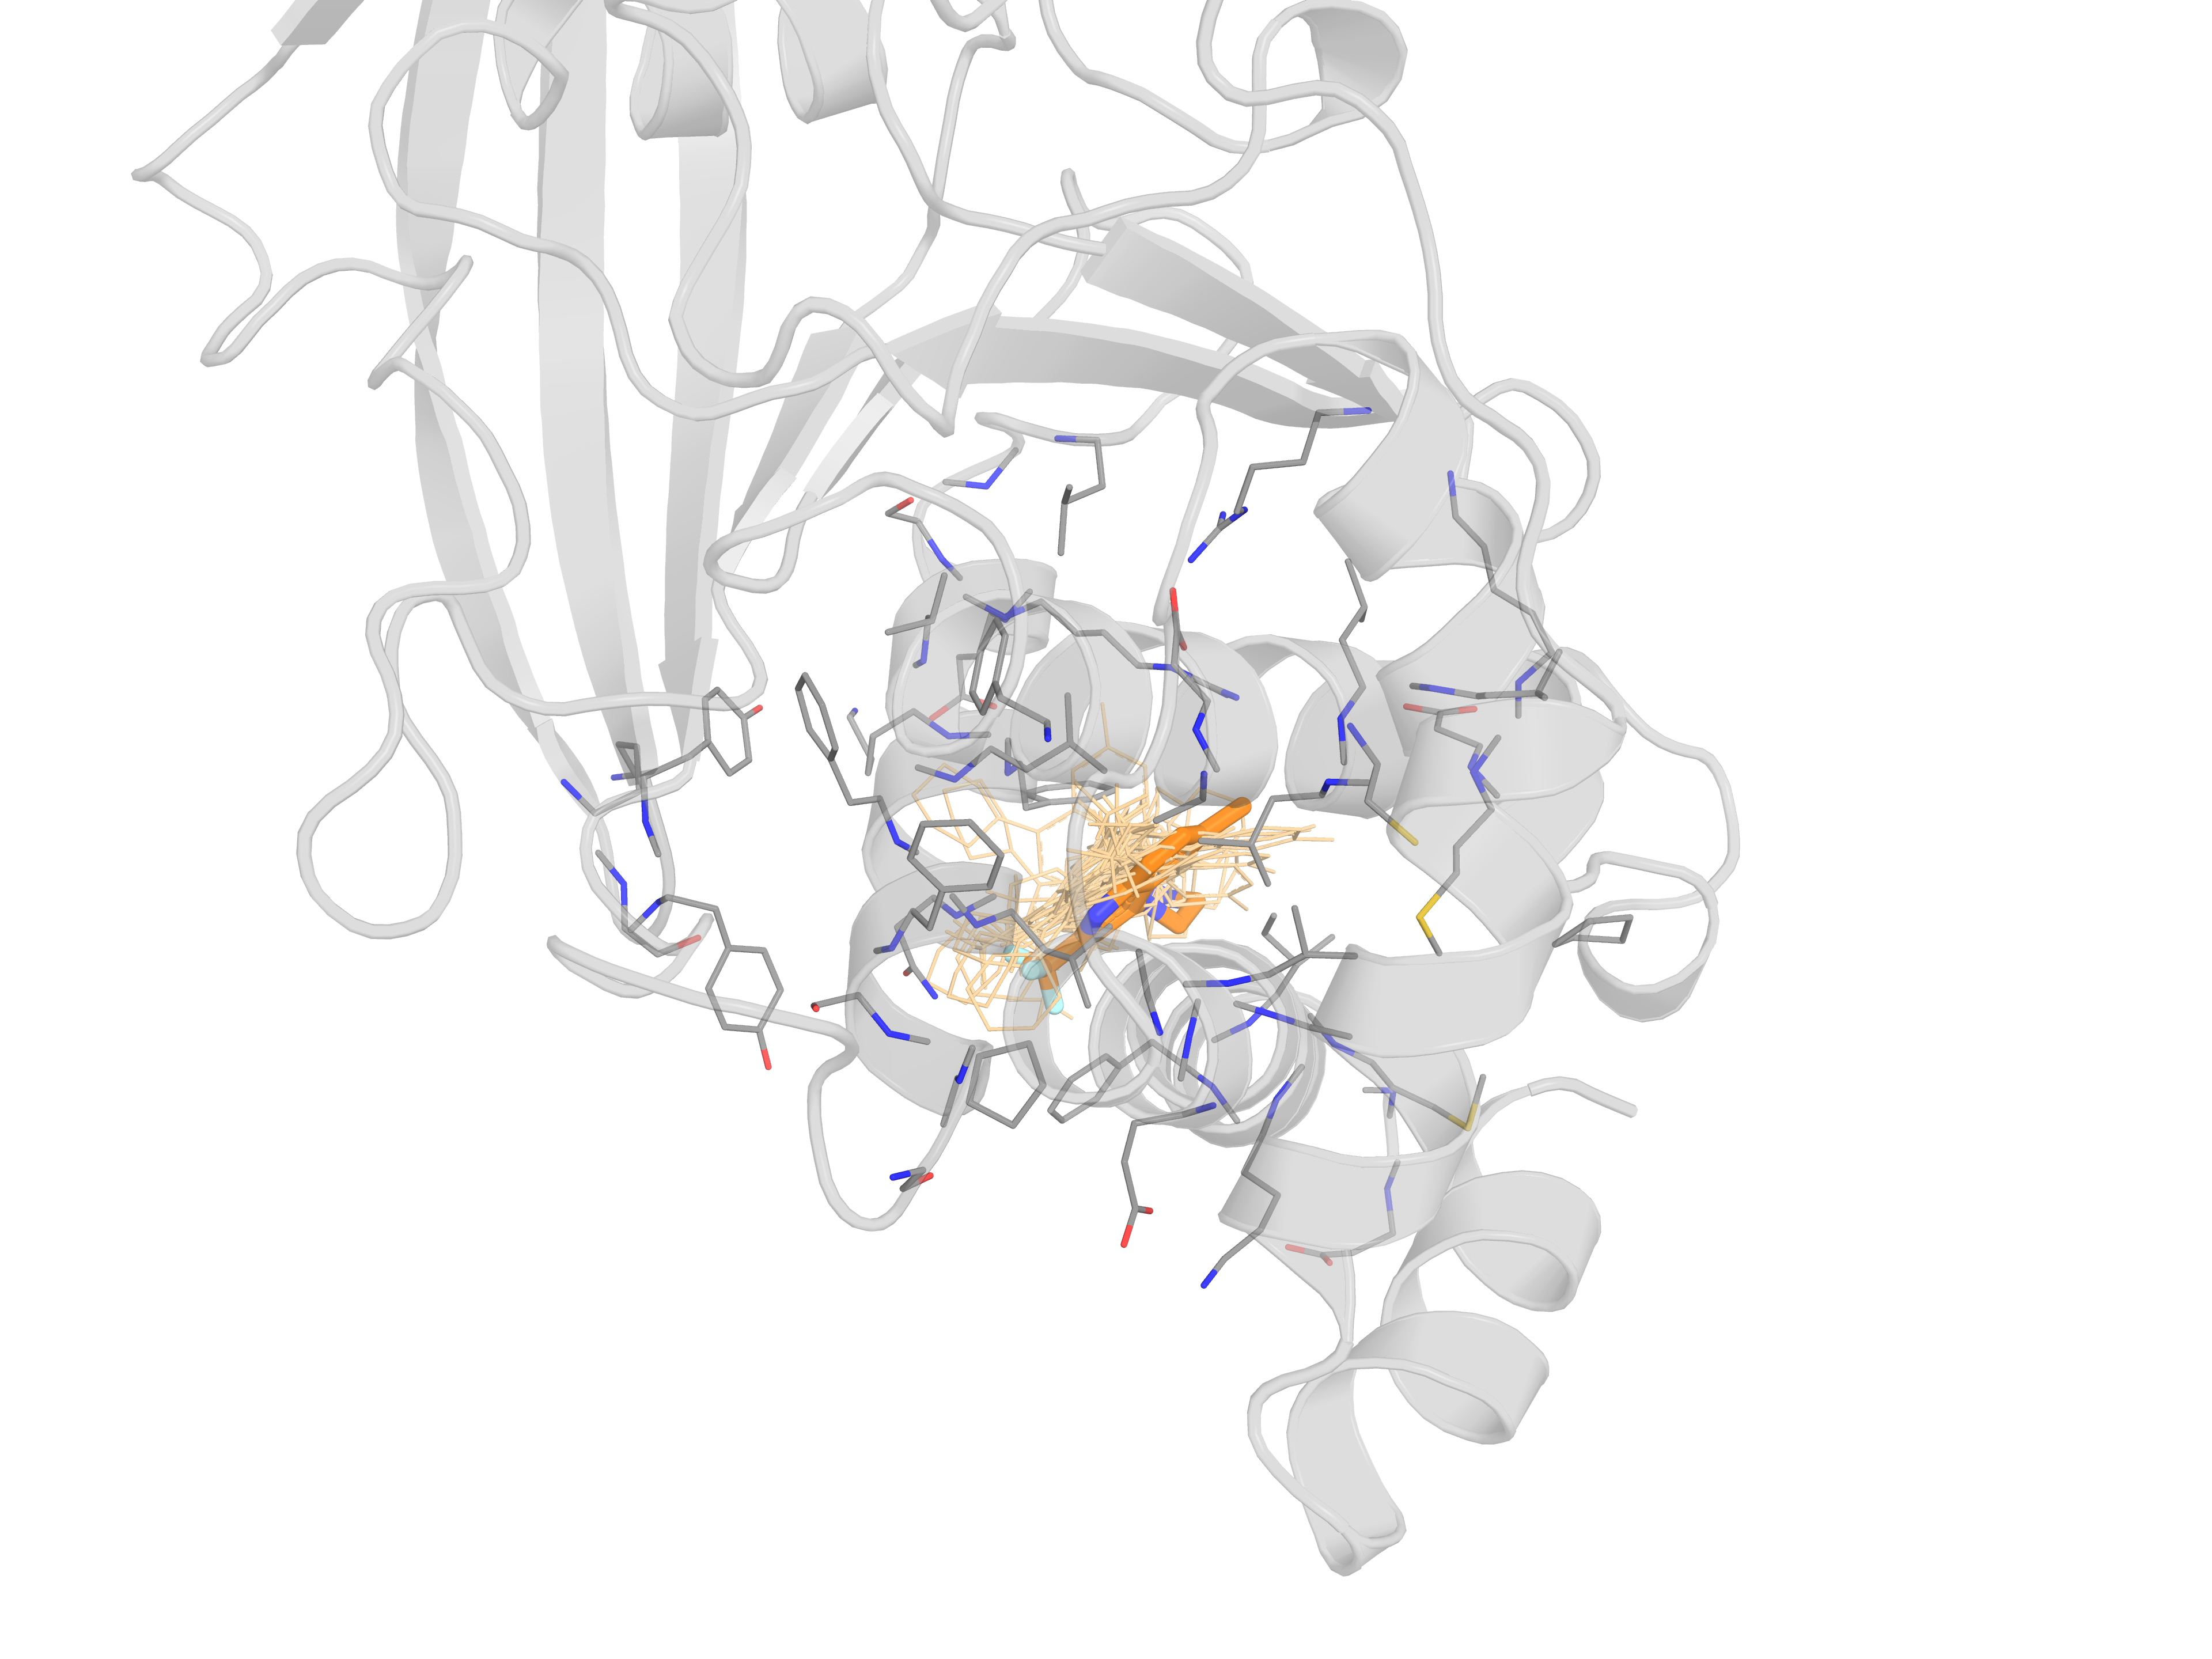

In [9]:
edge_dir = os.path.abspath("edges")
edge_infos = render.export_edge_structures(chi, K, edge_dir, verbose=True)
for info in edge_infos:
    i, j = info["edge"]
    pse = os.path.join(edge_dir, f"edge_{i}-{j}.pse")
    png = os.path.join(edge_dir, f"edge_{i}-{j}.png")
    ok, log = render._render_edge_one(info["dir"], pse, png)
    tag = " (RARE)" if info["rare"] else ""
    print(f"edge {i}-{j}{tag}: {info['n']} frames, s {info['s_lo']:.2f}->{info['s_hi']:.2f}"
          f"  -> {'OK' if ok else 'FAIL'} {os.path.basename(pse)}")
    if ok and os.path.exists(png):
        display(Image(filename=png, width=560))

## 7. Chi-sensitivity heatmap along all edges

`amore.chi.chi_sensitivity` gives per-atom average $\lVert\nabla_x s\rVert^2$, binned by
the edge coordinate $s_{ij}=\tfrac12(\chi_i-\chi_j+1)$ (`EdgeCV`) -- aggregated to residues
(sum over each residue's atoms, since this feature set's gradient is genuinely per-atom, not a
uniform COM split) and restricted to the top residues by peak sensitivity for readability.
Computed directly on **real** trajectory frames, on every edge that has genuine transition
frames (`A.edge_table`'s `transition` count, not the stricter vertex-purity `relevant` flag --
state 2 never reaches $\chi_2\ge0.8$ in this trajectory, so edge 1-2 would otherwise be
skipped despite 170 genuine transition-region frames; edge 0-2 has zero real transitions and is
excluded). A finer chi/edge-coordinate grid (50 bins over up to 500 frames per edge) than an
earlier version of this section used, which looked coarse/boxy at 20 bins over ~100 frames.

edge 0-2: 0 genuine transition frames -- skipping
edge 1-2: 500 frames, nbins=50


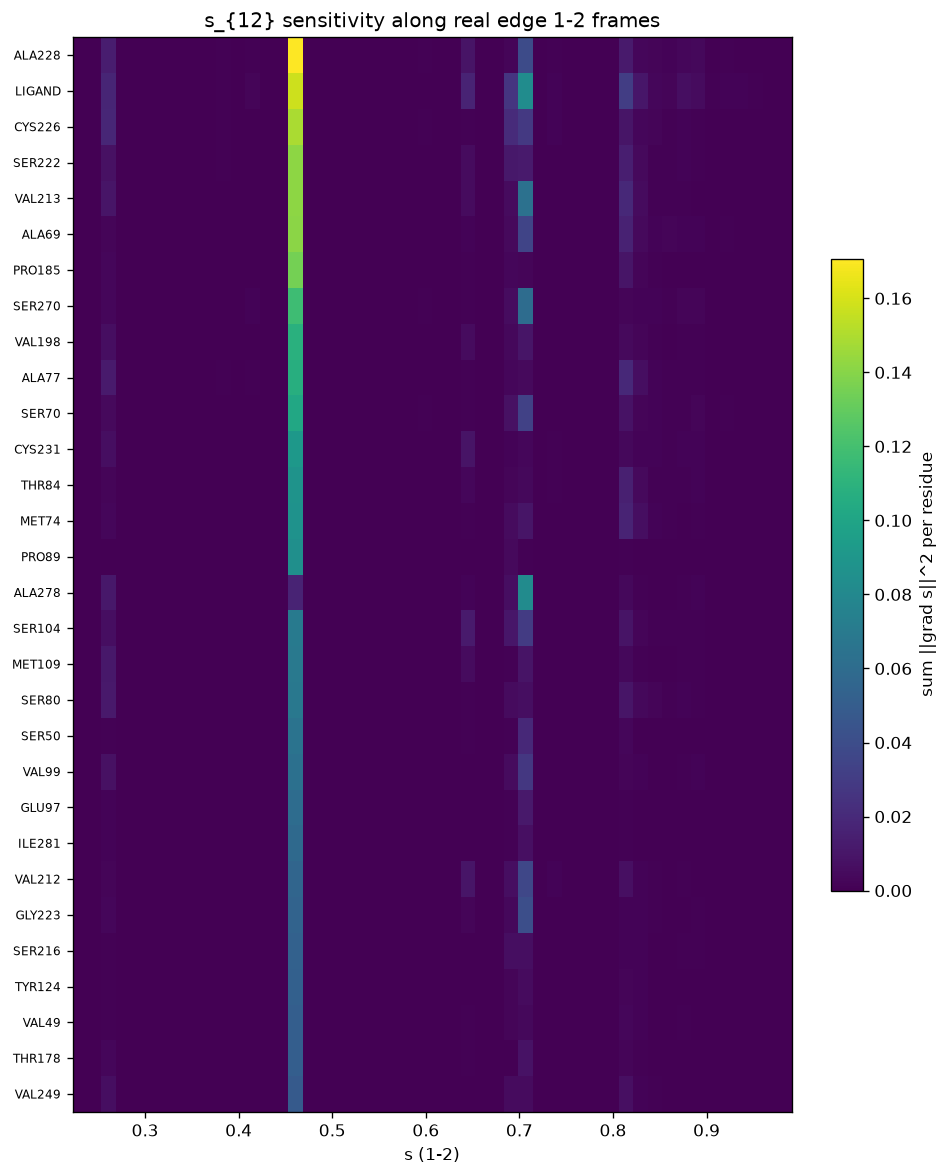

edge 0-1: 500 frames, nbins=50


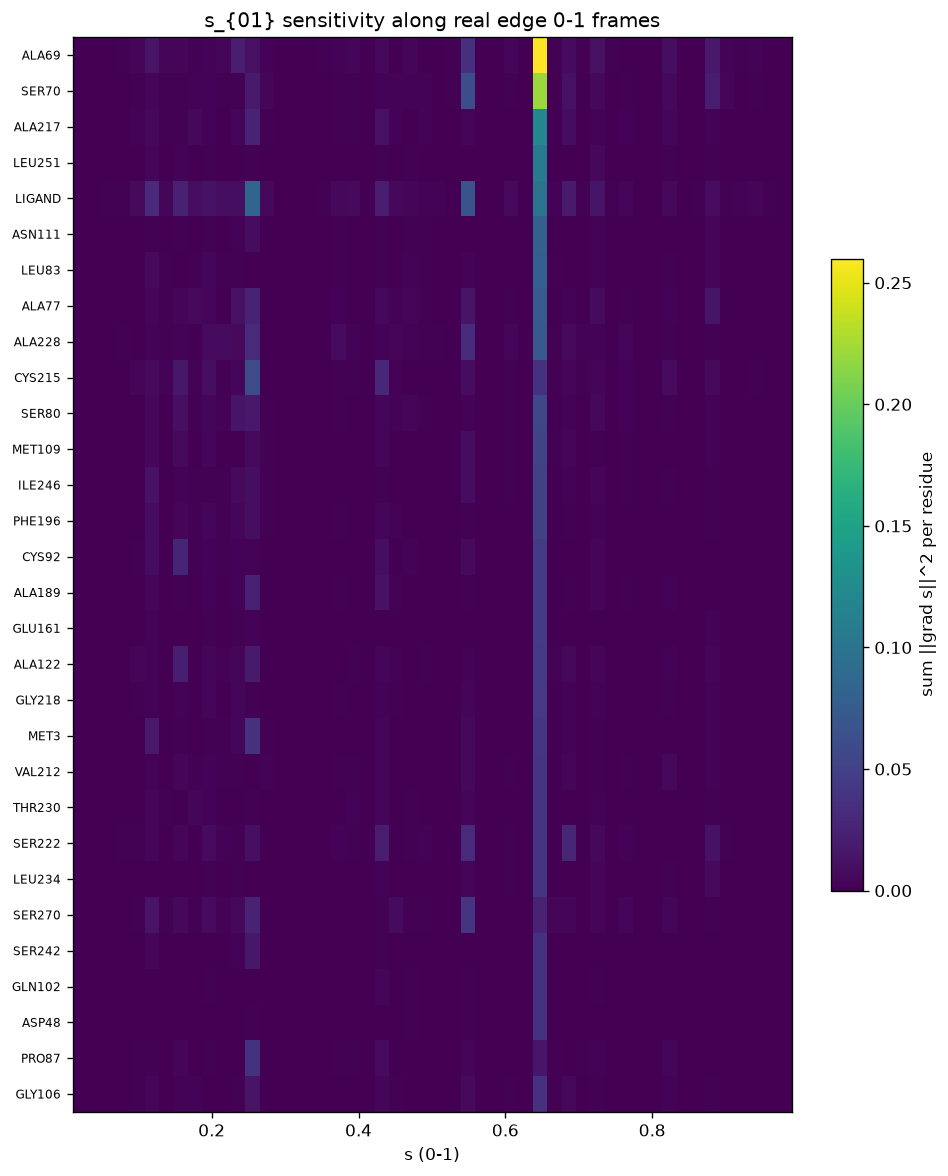

In [10]:
from amore.chi import chi_sensitivity
from amore.mep.simplex import EdgeCV
import MDAnalysis as mda

feat_fn = comfeat.make_torch_featurizer_pocket(device=DEVICE)
u_full = mda.Universe(data.pdb_path(), data.dcd_path())

def real_frame_positions_nm(anchor_idx):
    u_full.trajectory[NSTART + anchor_idx]
    return (u_full.atoms.positions.astype(np.float64) / 10.0).flatten()

u_top = mda.Universe(data.pdb_path())
prot_ag = u_top.select_atoms("protein")
lig_ag = u_top.select_atoms(f"resname {data.LIG_RESNAME}")
resindex_full = np.full(u_top.atoms.n_atoms, -1, dtype=int)
resindex_full[prot_ag.indices] = np.asarray(prot_ag.resindices)
LIG_LABEL = int(resindex_full[prot_ag.indices].max()) + 1
resindex_full[lig_ag.indices] = LIG_LABEL
res_label = {int(r.resindex): f"{r.resname}{r.resid}" for r in prot_ag.residues}
res_label[LIG_LABEL] = "LIGAND"
valid_atoms = resindex_full >= 0
n_res_total = LIG_LABEL + 1

def residue_sensitivity_heatmap(xs_np, cv, nbins, top_n=30, title="", xlabel="", fname=None):
    xs_t = torch.as_tensor(xs_np, dtype=torch.float32, device=DEVICE)
    bin_centers, avg_g2 = chi_sensitivity(cv, feat_fn, xs_t, nbins=nbins)
    bin_centers = bin_centers.detach().cpu().numpy(); avg_g2 = avg_g2.detach().cpu().numpy()
    agg = np.zeros((nbins, n_res_total))
    ridx = resindex_full[valid_atoms]
    for b in range(nbins):
        np.add.at(agg[b], ridx, avg_g2[b, valid_atoms])
    order = np.argsort(-agg.max(axis=0))[:top_n]
    labels = [res_label.get(idx, f"res{idx}") for idx in order]

    fig, ax = plt.subplots(figsize=(8, 0.28 * top_n + 1.5))
    im = ax.imshow(agg[:, order].T, aspect="auto", cmap="viridis", origin="upper",
                   extent=[bin_centers.min(), bin_centers.max(), top_n, 0])
    ax.set_yticks(np.arange(top_n) + 0.5); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel(xlabel); ax.set_title(title)
    plt.colorbar(im, ax=ax, label="sum ||grad s||^2 per residue", fraction=0.04)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=600, bbox_inches="tight")
    plt.show()
    return labels, agg[:, order], (bin_centers, agg)

NBINS, MAX_FRAMES = 50, 500
edge_sensitivity = {}
rows = A.edge_table(chi)
for r in rows:
    i, j = r["edge"]
    if r["transition"] == 0:
        print(f"edge {i}-{j}: 0 genuine transition frames -- skipping")
        continue
    order, s = A.pathway_frames(chi, i, j)
    if len(order) > MAX_FRAMES:
        pick = np.linspace(0, len(order) - 1, MAX_FRAMES).round().astype(int)
        order, s = order[pick], s[pick]
    nbins_i = min(NBINS, len(order))
    print(f"edge {i}-{j}: {len(order)} frames, nbins={nbins_i}")
    xyz = np.stack([real_frame_positions_nm(int(a)) for a in order])
    labels, agg, raw = residue_sensitivity_heatmap(
        xyz, EdgeCV(model, i, j), nbins=nbins_i,
        title=f"s_{{{i}{j}}} sensitivity along real edge {i}-{j} frames",
        xlabel=f"s ({i}-{j})", fname=f"sensitivity_edge_{i}-{j}.png")
    edge_sensitivity[(i, j)] = raw

## 8. PCA elbow plot on the training features

`feats["D0"]` is the exact feature matrix the network was trained on. A quick linear-PCA
scree plot -- not a substitute for the nonlinear ISA embedding above, but a cheap sanity
check on how much of the raw feature variance is concentrated in a few directions versus
spread out (a very slow-decaying curve would suggest the informative signal is genuinely
high-dimensional / nonlinear, not capturable by a handful of linear combinations).

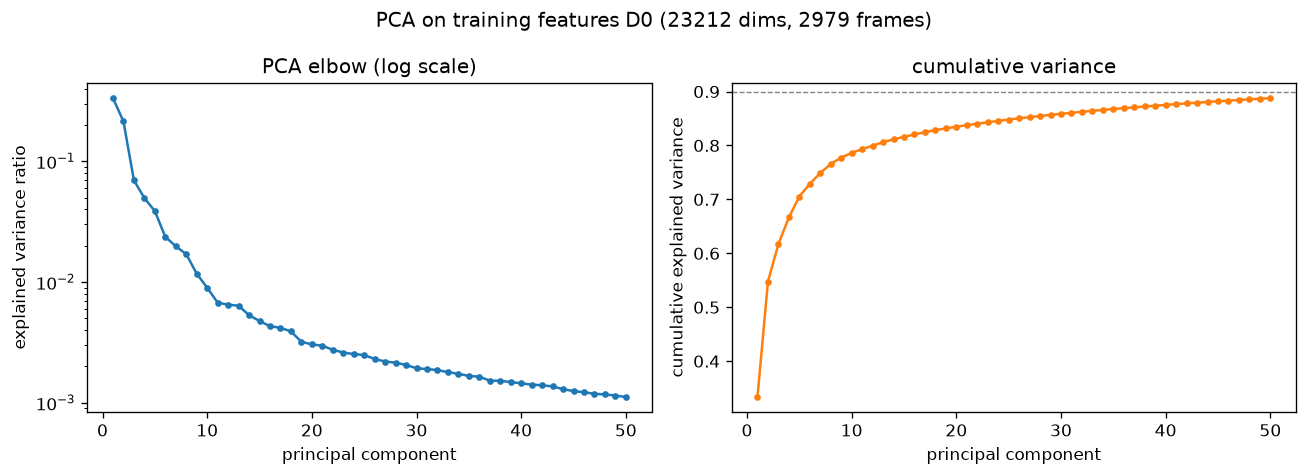

variance explained by first 50 PCs: 0.888


In [11]:
from sklearn.decomposition import PCA

D0_np = np.asarray(feats["D0"])
n_comp = min(50, *D0_np.shape)
pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=0).fit(D0_np)
evr = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(np.arange(1, n_comp + 1), evr, "o-", ms=3)
ax[0].set_yscale("log")
ax[0].set_xlabel("principal component"); ax[0].set_ylabel("explained variance ratio")
ax[0].set_title("PCA elbow (log scale)")
ax[1].plot(np.arange(1, n_comp + 1), np.cumsum(evr), "o-", ms=3, color="C1")
ax[1].set_xlabel("principal component"); ax[1].set_ylabel("cumulative explained variance")
ax[1].set_title("cumulative variance")
ax[1].axhline(0.9, color="grey", lw=0.8, ls="--")
plt.suptitle(f"PCA on training features D0 ({D0_np.shape[1]} dims, {D0_np.shape[0]} frames)")
plt.tight_layout()
plt.savefig("pca_elbow.png", dpi=600, bbox_inches="tight"); plt.show()
print(f"variance explained by first {n_comp} PCs: {evr.sum():.3f}")

## 9. Feature-space UMAP, cross-referenced against the chi memberships

Same aesthetic as the single-cell `amore.scrna.plotting` panels (`scatter_categorical` /
`scatter_chi`), but a different embedding: there, UMAP is built directly on the chi simplex
(`analysis.plot_chi_umap`, CUMAP via the Bhattacharyya affinity). Here UMAP is built on the
**training feature space** itself (the PCA reduction from section 8) -- a cross-reference
that's independent of the trained network's own output, showing whether the raw structural
data already separates into the same clusters the ISA memberships converged to (or reveals
structure the network didn't pick up on).

/home/htc/jkresse/AMORE/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


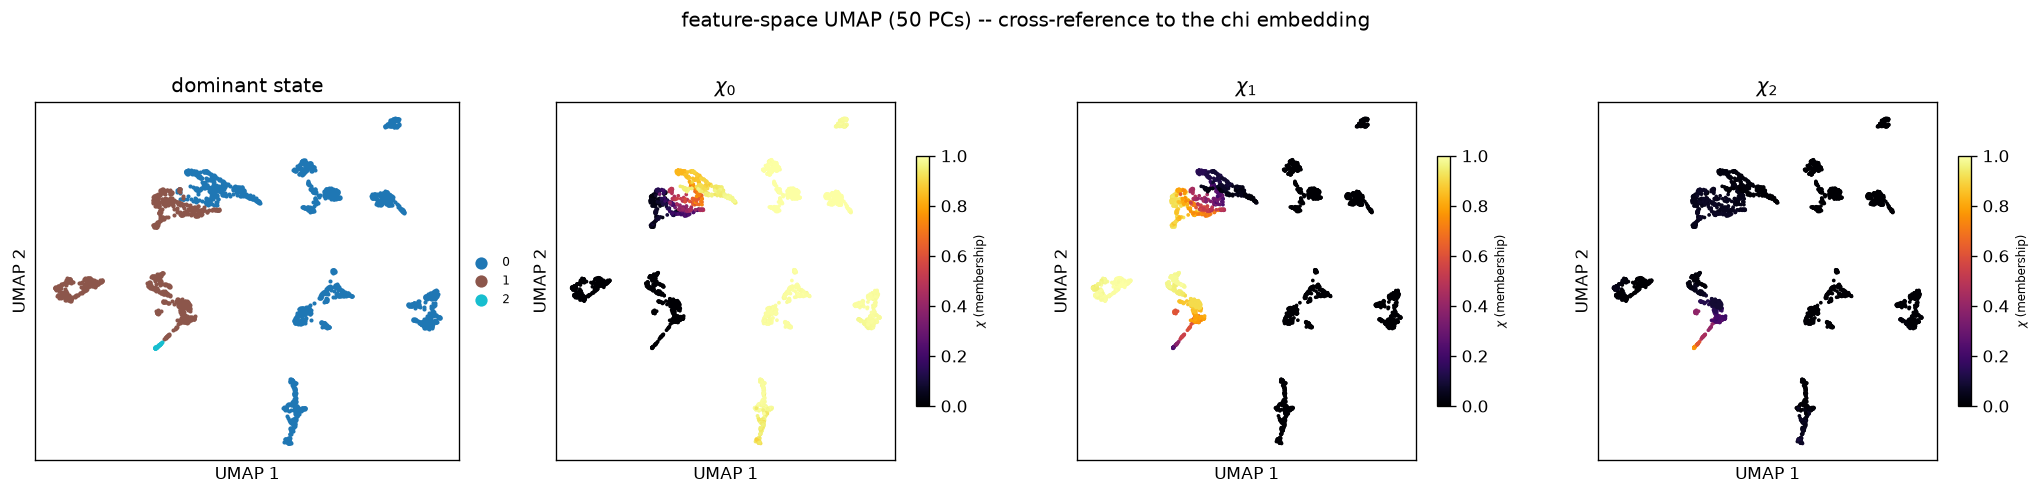

saved umap_features_emb.npy + umap_features_reducer.pkl (pca+reducer, for projecting path frames into this same embedding later)


In [12]:
import umap
from amore.scrna.plotting import scatter_categorical, scatter_chi

D0_pca = pca.transform(D0_np)                      # reuse the fit from section 8
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=0)
emb_feat = reducer.fit_transform(D0_pca)

fig, axes = plt.subplots(1, K + 1, figsize=(4.3 * (K + 1), 4))
scatter_categorical(axes[0], emb_feat, chi.argmax(1), title="dominant state", s=6, cmap="tab10",
                    xlabel="UMAP 1", ylabel="UMAP 2")
for i in range(K):
    scatter_chi(axes[i + 1], emb_feat, chi[:, i], title=f"$\chi_{i}$",
               cbar_label="$\chi$ (membership)", xlabel="UMAP 1", ylabel="UMAP 2")
fig.suptitle(f"feature-space UMAP ({n_comp} PCs) -- cross-reference to the chi embedding", y=1.02)
fig.tight_layout()
plt.savefig("umap_features_chi.png", dpi=600, bbox_inches="tight"); plt.show()

np.save("umap_features_emb.npy", emb_feat)
import pickle
with open("umap_features_reducer.pkl", "wb") as f:
    pickle.dump({"pca": pca, "reducer": reducer}, f)
print("saved umap_features_emb.npy + umap_features_reducer.pkl "
      "(pca+reducer, for projecting path frames into this same embedding later)")

### Summary

- **k = 3** softmax-ISA memberships trained on the pocket feature set (side-chain
  COM-COM + all-atom 5A ligand-protein contacts, PBC), full-trajectory anchors
  `[0, 2979)`.
- `chi` is recomputed fresh from `net_state` (self-consistency fix), not `run.get_model`'s
  cached `chi`.
- State/edge PyMOL renders below are the primary artifact for judging whether all
  3 states are genuinely structurally distinct on this new feature set.